In [ ]:
# BIVARIATE ANALYSIS
# Dataset: advanced_business_management_dataset(1).csv
# Purpose: Relationship Between Two Variables

In [1]:
# 1. Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
# 3. Load Dataset
# ============================================================

df = pd.read_csv("https://raw.githubusercontent.com/baren-kumar/Exploratory-Data-Analysis-EDA-/refs/heads/main/advanced_business_management_dataset.csv")

In [3]:
# 4. Display Dataset
# ============================================================

print("Dataset Shape:", df.shape)
display(df.head())

print("\nColumn Names:")
print(df.columns)

Dataset Shape: (500, 23)


,Order_ID,Date,Region,Product,Category,Salesperson,Customer_ID,Customer_Type,Marketing_Channel,Supplier,...,Delivery_Time_Days,Customer_Rating,Unit_Price,Unit_Cost,Gross_Sales,Discount_Amount,Net_Sales,Total_Cost,Profit,Profit_Margin
0,ORD-1379,2025-01-01,Sylhet,Tablet,Electronics,Rahim,CUST-605,Corporate,Direct Sales,Supplier B,...,12,2.8,46097,32059,1475104,280270,1194834,1025888,168946,0.141
1,ORD-1070,2025-01-01,Rajshahi,Printer,Office Equipment,Nila,CUST-197,Retail,Email,Supplier B,...,2,3.5,25297,16903,430049,30103,399946,287351,112595,0.282
2,ORD-1317,2025-01-02,Sylhet,Printer,Office Equipment,Sadia,CUST-128,Retail,Facebook,Supplier A,...,11,3.4,22765,17717,523595,68067,455528,407491,48037,0.105
3,ORD-1300,2025-01-02,Chittagong,Mobile,Electronics,Sadia,CUST-732,Corporate,Email,Supplier D,...,10,4.1,55764,33787,1226808,147217,1079591,743314,336277,0.311
4,ORD-1011,2025-01-04,Khulna,Monitor,Electronics,Tania,CUST-180,Retail,Email,Supplier B,...,3,2.8,34342,24428,686840,20605,666235,488560,177675,0.267



Column Names:
Index(['Order_ID', 'Date', 'Region', 'Product', 'Category', 'Salesperson',
       'Customer_ID', 'Customer_Type', 'Marketing_Channel', 'Supplier',
       'Units_Sold', 'Discount_Percent', 'Inventory_Level',
       'Delivery_Time_Days', 'Customer_Rating', 'Unit_Price', 'Unit_Cost',
       'Gross_Sales', 'Discount_Amount', 'Net_Sales', 'Total_Cost', 'Profit',
       'Profit_Margin'],
      dtype='object')


In [4]:
# 5. Basic Information
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            500 non-null    object 
 1   Date                500 non-null    object 
 2   Region              500 non-null    object 
 3   Product             500 non-null    object 
 4   Category            500 non-null    object 
 5   Salesperson         500 non-null    object 
 6   Customer_ID         500 non-null    object 
 7   Customer_Type       500 non-null    object 
 8   Marketing_Channel   500 non-null    object 
 9   Supplier            500 non-null    object 
 10  Units_Sold          500 non-null    int64  
 11  Discount_Percent    500 non-null    float64
 12  Inventory_Level     500 non-null    int64  
 13  Delivery_Time_Days  500 non-null    int64  
 14  Customer_Rating     500 non-null    float64
 15  Unit_Price          500 non-null   

,0
Order_ID,0
Date,0
Region,0
Product,0
Category,0
Salesperson,0
Customer_ID,0
Customer_Type,0
Marketing_Channel,0
Supplier,0


In [6]:
# 6. Select Two Variables for Bivariate Analysis
# Example 1: Discount_Percent vs Net_Sales
# Example 2: Unit_Price vs Units_Sold
# Example 3: Marketing_Channel vs Net_Sales
# ============================================================

x1 = df["Discount_Percent"]
y1 = df["Net_Sales"]

x2 = df["Unit_Price"]
y2 = df["Units_Sold"]

x3 = df["Marketing_Channel"]
y3 = df["Net_Sales"]

In [8]:
# 7. Correlation Analysis
# ============================================================

corr_discount_sales = x1.corr(y1)
corr_price_demand = x2.corr(y2)

# For categorical (Marketing_Channel) and numerical (Net_Sales) variables,
# correlation is not appropriate. Instead, we can analyze the mean Net_Sales
# for each Marketing_Channel.
mean_sales_by_channel = df.groupby('Marketing_Channel')['Net_Sales'].mean().sort_values(ascending=False)

print("========== BIVARIATE ANALYSIS ==========")
print("Discount Percent vs Net Sales (Correlation):", corr_discount_sales)
print("Unit Price vs Units Sold (Correlation):", corr_price_demand)
print("\nMean Net Sales by Marketing Channel:\n", mean_sales_by_channel)
print("========================================")

========== BIVARIATE ANALYSIS ==========
Discount Percent vs Net Sales (Correlation): -0.15847358436940645
Unit Price vs Units Sold (Correlation): 0.000309170339842641

Mean Net Sales by Marketing Channel:
 Marketing_Channel
Dealer          793939.529412
Facebook        788413.181818
Email           745493.415929
Direct Sales    689802.101010
Online          633243.701923
Name: Net_Sales, dtype: float64


In [10]:
# 8. Covariance Analysis
# ============================================================

cov_discount_sales = x1.cov(y1)
cov_price_demand = x2.cov(y2)
# Covariance is not appropriate for a categorical variable (Marketing_Channel)
# and a numerical variable (Net_Sales).

print("\n========== COVARIANCE ANALYSIS ==========")
print("Discount Percent vs Net Sales:", cov_discount_sales)
print("Unit Price vs Units Sold:", cov_price_demand)
print("Note: Covariance is not applicable for 'Marketing_Channel' vs 'Net_Sales' as 'Marketing_Channel' is categorical.")
print("=========================================")


========== COVARIANCE ANALYSIS ==========
Discount Percent vs Net Sales: -6890.116935791582
Unit Price vs Units Sold: 109.41579158318004
Note: Covariance is not applicable for 'Marketing_Channel' vs 'Net_Sales' as 'Marketing_Channel' is categorical.


In [12]:
# 9. Create Bivariate Summary Table
# ============================================================

bivariate_summary = pd.DataFrame({
    "Variable_X": [
        "Discount_Percent",
        "Unit_Price"
    ],
    "Variable_Y": [
        "Net_Sales",
        "Units_Sold"
    ],
    "Correlation": [
        corr_discount_sales,
        corr_price_demand
    ],
    "Covariance": [
        cov_discount_sales,
        cov_price_demand
    ]
})

print("\nBivariate Summary Table:")
display(bivariate_summary)


Bivariate Summary Table:


,Variable_X,Variable_Y,Correlation,Covariance
0,Discount_Percent,Net_Sales,-0.158474,-6890.116936
1,Unit_Price,Units_Sold,0.000309,109.415792


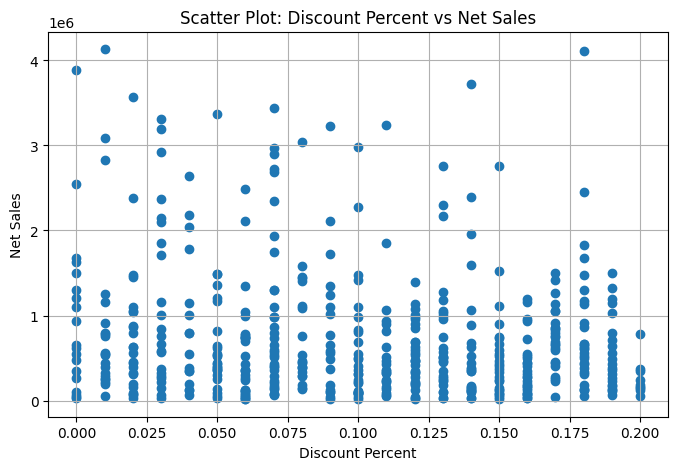

In [13]:
# 10. Scatter Plot: Discount Percent vs Net Sales
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(df["Discount_Percent"], df["Net_Sales"])
plt.title("Scatter Plot: Discount Percent vs Net Sales")
plt.xlabel("Discount Percent")
plt.ylabel("Net Sales")
plt.grid(True)
plt.show()

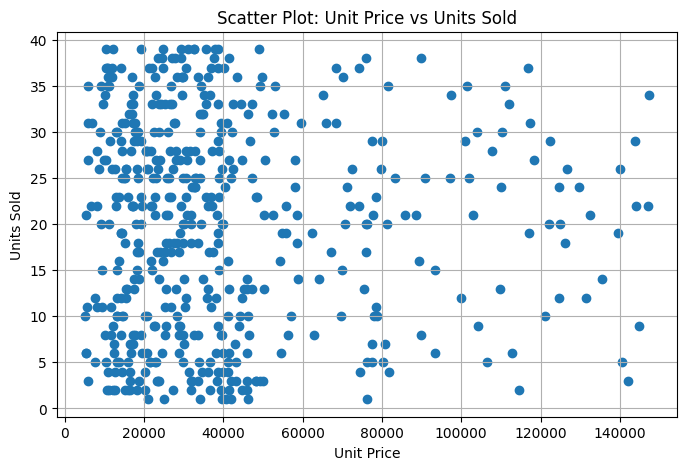

In [14]:
# 11. Scatter Plot: Unit Price vs Units Sold
# Price vs Demand
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(df["Unit_Price"], df["Units_Sold"])
plt.title("Scatter Plot: Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()

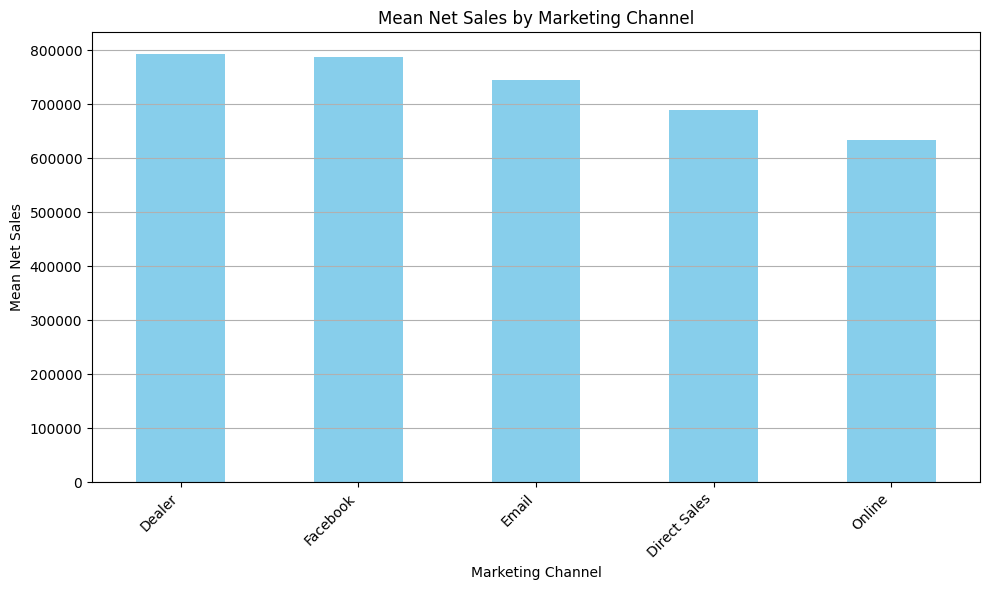

In [16]:
# 12. Bar Chart: Marketing Channel vs Net Sales
# ============================================================

# Calculate mean Net Sales by Marketing Channel
mean_sales_by_channel = df.groupby('Marketing_Channel')['Net_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
mean_sales_by_channel.plot(kind='bar', color='skyblue')
plt.title("Mean Net Sales by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Mean Net Sales")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

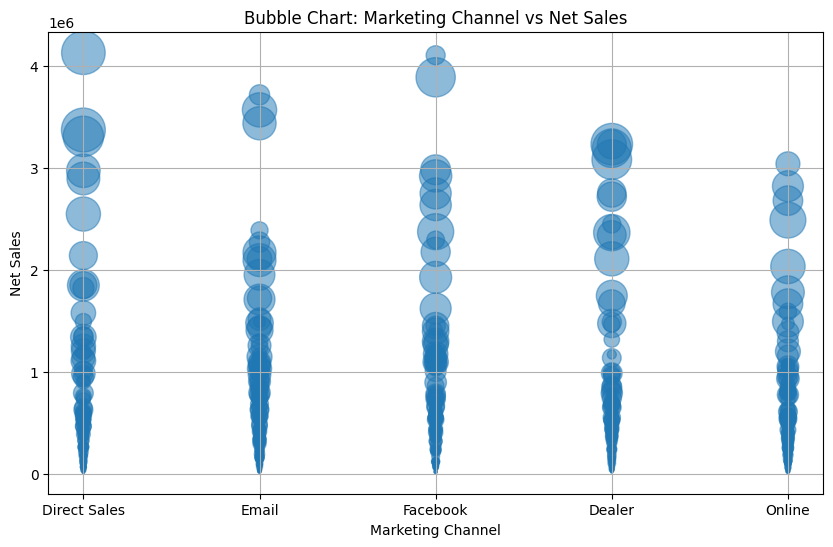

In [18]:
# 13. Bubble Chart
# X = Marketing Channel
# Y = Net Sales
# Bubble Size = Profit
# ============================================================

bubble_size = df["Profit"].abs() / df["Profit"].abs().max() * 1000

plt.figure(figsize=(10,6))
plt.scatter(
    df["Marketing_Channel"],
    df["Net_Sales"],
    s=bubble_size,
    alpha=0.5
)

plt.title("Bubble Chart: Marketing Channel vs Net Sales")
plt.xlabel("Marketing Channel")
plt.ylabel("Net Sales")
plt.grid(True)
plt.show()

In [19]:
# 14. Full Correlation Matrix
# ============================================================

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

print("\nFull Correlation Matrix:")
display(correlation_matrix)


Full Correlation Matrix:


,Units_Sold,Discount_Percent,Inventory_Level,Delivery_Time_Days,Customer_Rating,Unit_Price,Unit_Cost,Gross_Sales,Discount_Amount,Net_Sales,Total_Cost,Profit,Profit_Margin
Units_Sold,1.000000,-0.008240,0.014074,-0.018976,-0.027846,0.000309,0.008149,0.518010,0.390677,0.513255,0.513069,0.427542,-0.026582
Discount_Percent,-0.008240,1.000000,0.051803,-0.097837,-0.043608,-0.076743,-0.060994,-0.097309,0.422750,-0.158474,-0.080750,-0.330497,-0.528253
Inventory_Level,0.014074,0.051803,1.000000,-0.031238,-0.003222,-0.005626,-0.006920,-0.007407,0.043668,-0.013500,-0.009766,-0.020774,0.032372
Delivery_Time_Days,-0.018976,-0.097837,-0.031238,1.000000,-0.126336,-0.037222,-0.029470,-0.039906,-0.089362,-0.032127,-0.035339,-0.018523,0.016990
Customer_Rating,-0.027846,-0.043608,-0.003222,-0.126336,1.000000,0.034057,0.013161,0.012891,-0.054298,0.020780,-0.009392,0.094399,0.099736
Unit_Price,0.000309,-0.076743,-0.005626,-0.037222,0.034057,1.000000,0.985153,0.763252,0.552912,0.759087,0.746215,0.664515,0.051051
Unit_Cost,0.008149,-0.060994,-0.006920,-0.029470,0.013161,0.985153,1.000000,0.761722,0.575269,0.754630,0.767699,0.594509,-0.072516
Gross_Sales,0.518010,-0.097309,-0.007407,-0.039906,0.012891,0.763252,0.761722,1.000000,0.711709,0.996132,0.988953,0.847205,0.028656
Discount_Amount,0.390677,0.422750,0.043668,-0.089362,-0.054298,0.552912,0.575269,0.711709,1.000000,0.647232,0.726992,0.334706,-0.289158
Net_Sales,0.513255,-0.158474,-0.013500,-0.032127,0.020780,0.759087,0.754630,0.996132,0.647232,1.000000,0.982233,0.877482,0.067264


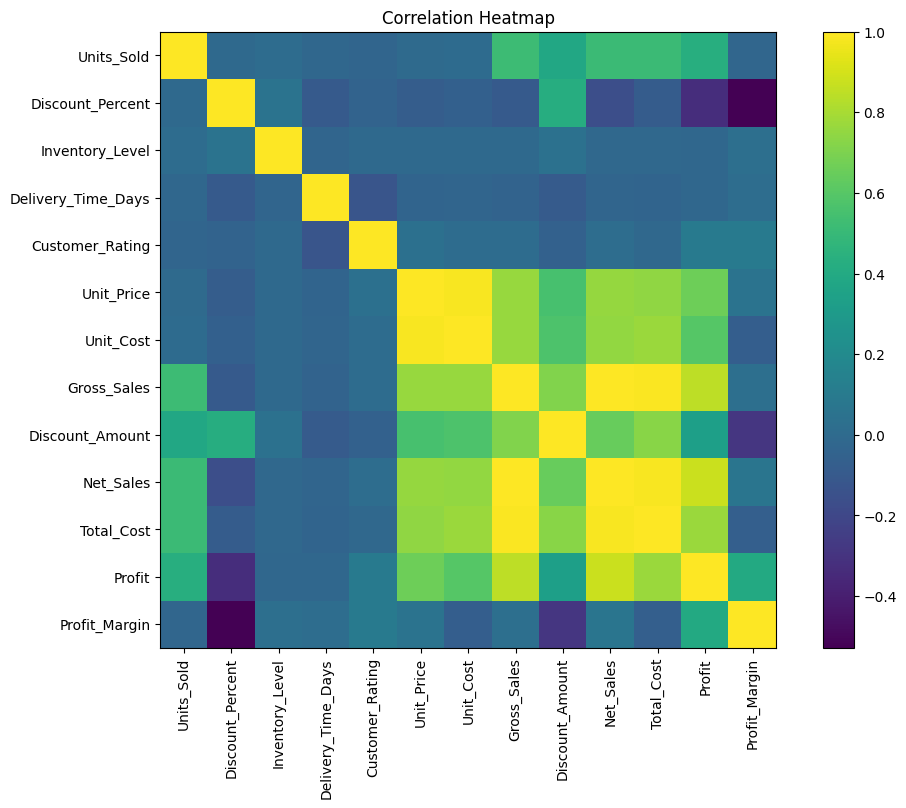

In [20]:
# 15. Heatmap using Matplotlib
# ============================================================

plt.figure(figsize=(12,8))
plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
# 16. Cross-tabulation
# Example: Region vs Category
# ============================================================

cross_tab_region_category = pd.crosstab(
    df["Region"],
    df["Category"]
)

print("\nCross-tabulation: Region vs Category")
display(cross_tab_region_category)


Cross-tabulation: Region vs Category


Category,Electronics,Furniture,Office Equipment
Region,,,
Chittagong,59,16,15
Dhaka,64,28,20
Khulna,51,29,13
Rajshahi,61,24,19
Sylhet,52,30,19



Cross-tabulation: Region vs Category by Net Sales


Category,Electronics,Furniture,Office Equipment
Region,,,
Chittagong,71268074,4920415,10015345
Dhaka,64728546,9381002,8489917
Khulna,38939569,9326730,6006544
Rajshahi,61721301,5476760,7749412
Sylhet,47529154,9595985,8777520


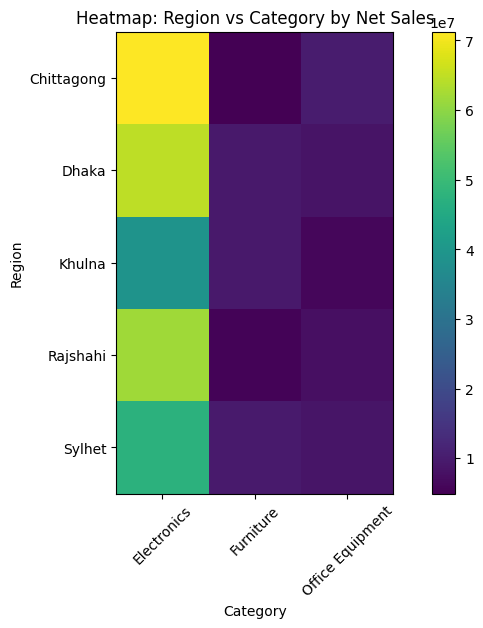

In [22]:
# 17. Cross-tabulation with Sales Value
# Region vs Category by Net Sales
# ============================================================

cross_tab_sales = pd.pivot_table(
    df,
    values="Net_Sales",
    index="Region",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

print("\nCross-tabulation: Region vs Category by Net Sales")
display(cross_tab_sales)

plt.figure(figsize=(10,6))
plt.imshow(cross_tab_sales)

plt.colorbar()
plt.xticks(
    range(len(cross_tab_sales.columns)),
    cross_tab_sales.columns,
    rotation=45
)
plt.yticks(
    range(len(cross_tab_sales.index)),
    cross_tab_sales.index
)

plt.title("Heatmap: Region vs Category by Net Sales")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()

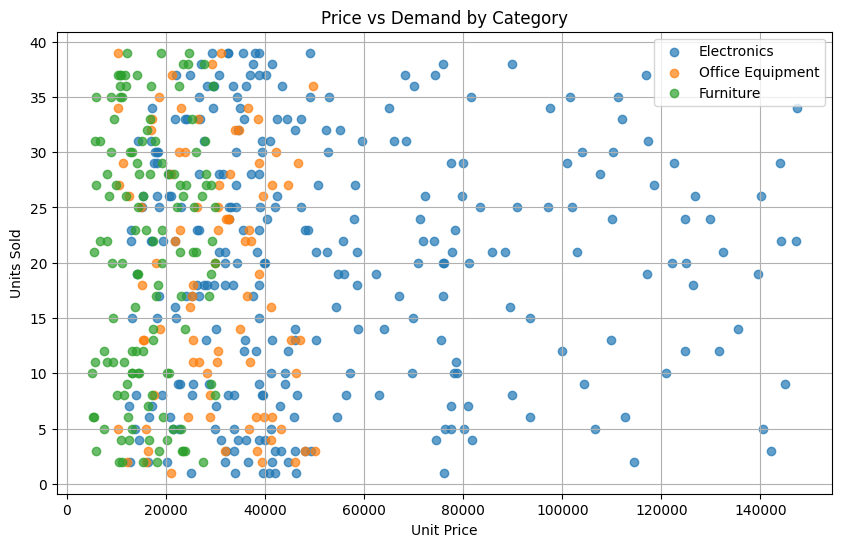

In [23]:
# 18. Relationship by Category
# Unit Price vs Units Sold
# ============================================================

categories = df["Category"].unique()

plt.figure(figsize=(10,6))

for category in categories:
    subset = df[df["Category"] == category]
    plt.scatter(
        subset["Unit_Price"],
        subset["Units_Sold"],
        label=category,
        alpha=0.7
    )

plt.title("Price vs Demand by Category")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.show()

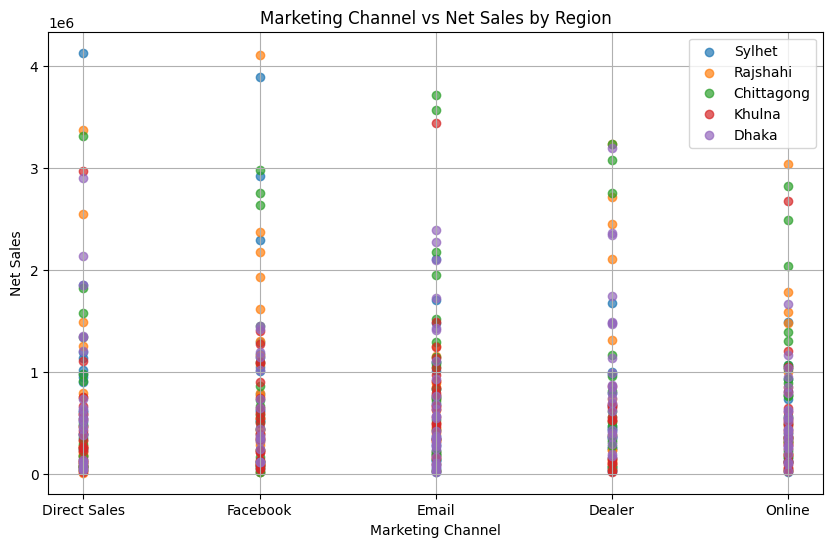

In [25]:
# 19. Relationship by Region
# Marketing Channel vs Net Sales
# ============================================================

regions = df["Region"].unique()

plt.figure(figsize=(10,6))

for region in regions:
    subset = df[df["Region"] == region]
    plt.scatter(
        subset["Marketing_Channel"],
        subset["Net_Sales"],
        label=region,
        alpha=0.7
    )

plt.title("Marketing Channel vs Net Sales by Region")
plt.xlabel("Marketing Channel")
plt.ylabel("Net Sales")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# 20. Save Bivariate Analysis Results to Excel
# ============================================================

excel_file = "Bivariate_Analysis_Report.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    bivariate_summary.to_excel(writer, sheet_name="Bivariate_Summary", index=False)
    correlation_matrix.to_excel(writer, sheet_name="Correlation_Matrix")
    cross_tab_region_category.to_excel(writer, sheet_name="Region_Category_Count")
    cross_tab_sales.to_excel(writer, sheet_name="Region_Category_Sales")

print("\nExcel report saved successfully!")


Excel report saved successfully!


In [27]:
# 21. Download Excel File
# ============================================================

files.download(excel_file)

print("\nBivariate Analysis Completed Successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Bivariate Analysis Completed Successfully!
